In [1]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')

**customers — таблица с уникальными идентификаторами пользователей**

- customer_id — позаказный идентификатор пользователя

- customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)

- customer_zip_code_prefix — почтовый индекс пользователя

- customer_city — город доставки пользователя

- customer_state — штат доставки пользователя

In [3]:
customers.shape

(99441, 5)

In [4]:
customers.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [5]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [6]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

**orders — таблица заказов**

- order_id — уникальный идентификатор заказа (номер чека)

- customer_id — позаказный идентификатор пользователя

- order_status — статус заказа

- order_purchase_timestamp — время создания заказа

- order_approved_at — время подтверждения оплаты заказа

- order_delivered_carrier_date — время передачи заказа в логистическую службу

- order_delivered_customer_date — время доставки заказа

- order_estimated_delivery_date — обещанная дата доставки

In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.shape 

(99441, 8)

In [9]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [10]:
orders.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [11]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**order_items —  товарные позиции, входящие в заказы** 

- order_id — уникальный идентификатор заказа (номер чека)

- order_item_id — идентификатор товара внутри одного заказа

- product_id — ид товара (аналог штрихкода)

- seller_id — ид производителя товара

- shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике

- price — цена за единицу товара

- freight_value — вес товара 

In [12]:
order_items.query('order_item_id > 1')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
43,001ab0a7578dd66cd4b0a71f5b6e1e41,2,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
44,001ab0a7578dd66cd4b0a71f5b6e1e41,3,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
...,...,...,...,...,...,...,...
112617,ffecd5a79a0084f6a592288c67e3c298,3,50fd2b788dc166edd20512370dac54df,8b321bb669392f5163d04c59e235e066,2018-03-05 20:15:27,21.90,15.79
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


In [13]:
order_items.shape

(112650, 7)

In [14]:
order_items.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

# Оценить месячный retention в оформление заказа с помощью когортного анализа.

Посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

Для этого вам нужно:

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

В рамках исследования необходимо:

- Исследовать датасет и определить, какой вид заказа будет учитываться в retention
- Построить месячный retention
- Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)
- Найти когорту с самым высоким retention на 3-й месяц.
- Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

In [15]:
# посмотрим, какая часть заказов имеют статус 'delivered'
orders.groupby('order_status').order_id.count().div(orders.shape[0]).mul(100).round(3)

# 97% заказов имеют статус 'delivered'

order_status
approved        0.002
canceled        0.629
created         0.005
delivered      97.020
invoiced        0.316
processing      0.303
shipped         1.113
unavailable     0.612
Name: order_id, dtype: float64

In [16]:
# Считаем количество товаров и сумму заказа
average_order = order_items.groupby('order_id', as_index=False).agg(
    item_count=('order_item_id', 'max'),
    order_total=('price', 'sum')
)

# преобразуем время создания заказа в тип datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [17]:
# объединяем данные
data_merged = (
    average_order
    .merge(orders, on='order_id', how='outer')
    .merge(customers[['customer_unique_id', 'customer_id', 'customer_state']], on='customer_id', how='outer')
    [['order_id', 'customer_unique_id', 'order_status', 'order_total', 'item_count', 
      'order_purchase_timestamp', 'order_approved_at',
      'order_delivered_carrier_date', 'order_delivered_customer_date',
      'order_estimated_delivery_date', 'customer_state']]
)

# извлекаем день и месяц заказа
data_merged['purchase_date'] = data_merged['order_purchase_timestamp'].dt.to_period('D')
data_merged['purchase_month'] = data_merged['order_purchase_timestamp'].dt.to_period('M')

In [18]:
# оставим только заказы со статусом 'delivered'
delivered_orders = data_merged[data_merged['order_status'] == 'delivered'].copy()

delivered_orders

,order_id,customer_unique_id,order_status,order_total,item_count,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,purchase_date,purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,delivered,58.90,1.0,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,RJ,2017-09-13,2017-09
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,delivered,239.90,1.0,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,SP,2017-04-26,2017-04
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,delivered,199.00,1.0,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,MG,2018-01-14,2018-01
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,delivered,12.99,1.0,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,SP,2018-08-08,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,delivered,199.90,1.0,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,SP,2017-02-04,2017-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,0c9aeda10a71f369396d0c04dce13a64,delivered,299.99,1.0,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00,MA,2018-04-23,2018-04
98662,fffcd46ef2263f404302a634eb57f7eb,0da9fe112eae0c74d3ba1fe16de0988b,delivered,350.00,1.0,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00,PR,2018-07-14,2018-07
98663,fffce4705a9662cd70adb13d4a31832d,cd79b407828f02fdbba457111c38e4c4,delivered,99.90,1.0,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00,SP,2017-10-23,2017-10
98664,fffe18544ffabc95dfada21779c9644f,eb803377c9315b564bdedad672039306,delivered,55.99,1.0,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00,SP,2017-08-14,2017-08


In [19]:
# присваиваем когорты на основе даты первого создания заказа для каждого пользователя
delivered_orders['cohort'] = (delivered_orders
                .groupby('customer_unique_id')['order_purchase_timestamp']
                .transform('min')
                .dt.to_period('M')
               )

delivered_orders['cohort_day'] = (delivered_orders
                    .groupby('customer_unique_id')['order_purchase_timestamp']
                    .transform('min')
                    .dt.to_period('D')
                   )

# считаем номер периода жизни пользователя в днях
delivered_orders['period_number_month'] = (np.floor((delivered_orders.purchase_date - delivered_orders.cohort_day)
                                      .apply(attrgetter('n')) / 30))

delivered_orders.head()

,order_id,customer_unique_id,order_status,order_total,item_count,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,purchase_date,purchase_month,cohort,cohort_day,period_number_month
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,delivered,58.90,1.0,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,RJ,2017-09-13,2017-09,2017-09,2017-09-13,0.0
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,delivered,239.90,1.0,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,SP,2017-04-26,2017-04,2017-04,2017-04-26,0.0
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,delivered,199.00,1.0,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,MG,2018-01-14,2018-01,2018-01,2018-01-14,0.0
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,delivered,12.99,1.0,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,SP,2018-08-08,2018-08,2018-08,2018-08-08,0.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,delivered,199.90,1.0,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,SP,2017-02-04,2017-02,2017-02,2017-02-04,0.0


In [20]:
# агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
delivered_orders_cohort = (delivered_orders
             .groupby(['cohort', 'period_number_month'])
             .agg(n_customers=('customer_unique_id', 'nunique'))
             .reset_index()
            )

delivered_orders_cohort

,cohort,period_number_month,n_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1
...,...,...,...
210,2018-06,1.0,22
211,2018-06,2.0,6
212,2018-07,0.0,5949
213,2018-07,1.0,6


In [21]:
# создаем сводную таблицу для когортного анализа
cohort_pivot = delivered_orders_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

cohort_pivot.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN,NaN


In [22]:
# рассчитываем размеры когорт (первый столбец сводной таблицы). 
cohort_size = delivered_orders.groupby('cohort')['customer_unique_id'].nunique()

# считаем коэффициенты удержания
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN


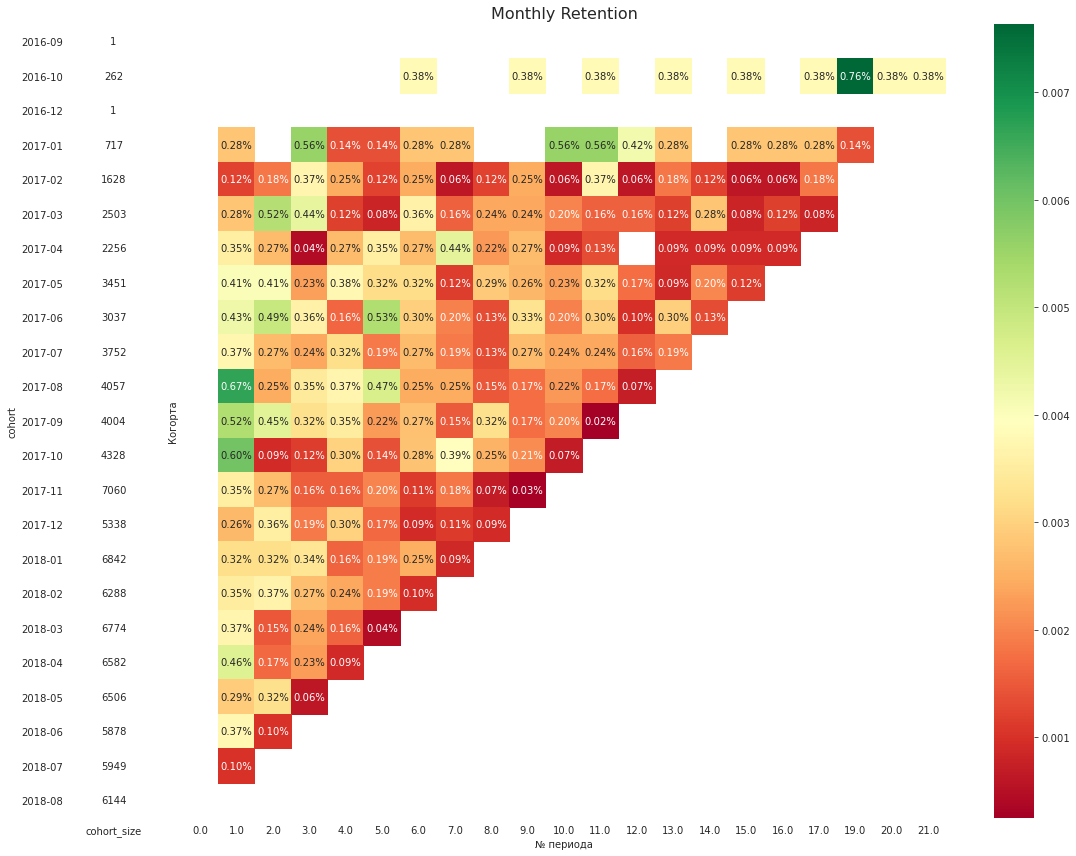

In [23]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # строим тепловую карту для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.iloc[:, 1:].isnull(), # убираем 0 период, т.к. его наличие искажает цветовую шкалу визуализации и затрудняет интерпретацию результатов в последующие месяцы 
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # строим тепловую карту для размеров когорт
    cohort_size_df = cohort_size.to_frame(name='cohort_size')
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [24]:
# медианный retention 1-го месяца
retention_1_median = round(retention_matrix[1].median() * 100, 4)

print(f'Медианный retention 1-го месяца = {retention_1_median}%')

Медианный retention 1-го месяца = 0.3546%


In [25]:
# максимальный retention на 3 месяц
cohort_max_3 = retention_matrix[3].idxmax()
retention_max_3 = round(retention_matrix[3].max() * 100, 4)

print(f'Когорта с максимальным retention на 3 месяц: {cohort_max_3} (retention = {retention_max_3}%)')

Когорта с максимальным retention на 3 месяц: 2017-01 (retention = 0.5579%)


## Краткие выводы по задаче 1:
    
1. Для расчета retention были использованы заказы со статусом **'delivered'**, так как это значит, что клиент точно совершил покупку и заказ завершен (клиент не отменил заказ). 
2. Медианный retention 1-го месяца равен **0.3546%**
3. Самый высокий retention на 3 месяц зафиксирован в **январской когорте 2017 года** и равен **0.5579%**

# Определить, существует ли product/market fit у маркетплейса.

Оценим, насколько хорошо продукт закрывает потребности клиента.

В рамках исследования необходимо:

- Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
- Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
- Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

In [26]:
# посмотрим на медианный retention в каждый месяц
retention_curve = retention_matrix.median() * 100
retention_curve = retention_curve.rename('retention').reset_index().rename(columns={'period_number_month' : 'period'})

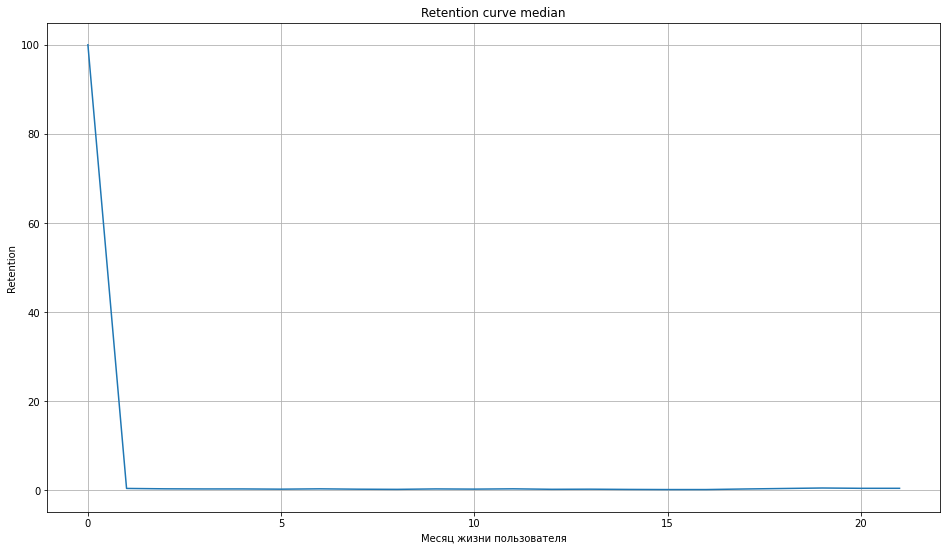

In [27]:
plt.figure(figsize=(16, 9))

sns.lineplot(data=retention_curve, x='period', y='retention')

plt.title("Retention curve median")
plt.xlabel('Месяц жизни пользователя')
plt.ylabel('Retention')

plt.grid(True)
plt.show()

In [28]:
# проверим есть ли проблемы с логистикой и доставкой товаров. Для этого посмотрим, сколько заказов были доставлены с задержкой
delayed_orders = orders.query("order_status == 'delivered' & order_estimated_delivery_date <= order_delivered_customer_date")

share_delayed = round(delayed_orders.shape[0] / orders.shape[0] * 100, 2)

print(f'Доля заказов, доставленных с опозданием: {share_delayed}%')

Доля заказов, доставленных с опозданием: 7.87%


In [29]:
# посмотрим, сколько времени проходит между размещением заказа, оплатой, передачей в логистическую службу (сборкой) и доставкой
orders_path = orders.copy()

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

orders_path[date_cols] = orders_path[date_cols].apply(pd.to_datetime)

orders_path['time_to_payment'] = orders_path['order_approved_at'] - orders_path['order_purchase_timestamp']
orders_path['time_delivery_to_carrier'] = orders_path['order_delivered_carrier_date'] - orders_path['order_approved_at'] 
orders_path['time_delivery_to_customer'] = orders_path['order_delivered_customer_date'] - orders_path['order_delivered_carrier_date']

orders_path.describe()

,time_to_payment,time_delivery_to_carrier,time_delivery_to_customer
count,99281,97644,96475
mean,0 days 10:25:08.739486910,2 days 19:19:15.298850927,9 days 07:55:59.254148743
std,1 days 02:02:16.813098347,3 days 13:11:10.497083683,8 days 18:14:34.522067763
min,0 days 00:00:00,-172 days +18:44:38,-17 days +21:41:31
25%,0 days 00:12:54,0 days 21:00:44,4 days 02:23:55.500000
50%,0 days 00:20:36,1 days 19:38:29.500000,7 days 02:23:40
75%,0 days 14:34:51,3 days 13:55:52.500000,12 days 00:41:55.500000
max,187 days 21:10:50,125 days 18:18:06,205 days 04:35:00


Среднее время оплаты заказа составляет 20 минут. Среднее время передачи в логистическую службу составляет 1 день 20 часов. Показатель в целом не сильно большой, но максимальный срок передачи в логистическую службу (время сборки) - 125 дней. Среднее время доставки клиенту составляет 7 дней, что в целом не сильно долго (хотя, возможно, у конкурентов доставка быстрее,из-за чего клиенты могут делать выбор не в пользу нашего маркетплейса), однако видно, что максимальный срок доставки клиенту был 205 дней.

In [30]:
orders_path.query('time_to_payment > @pd.Timedelta(days=1)').shape

(17419, 11)

## Краткие выводы по задаче 2:

Для оценки PMF был проведен когортный анализ, а также построена кривая по медианным retention, отражающая динамику возвращаемости пользователей.

По графику видно, что медианный retention резко снижается после 0-го месяца и стабилизируется на значении меньше 0.5%, MAU резко падает, устойчивое плато хоть и наблюдается, но на очень низком уровне, **PFM отсутствует**. 

Это говорит о том, что большинство пользователей совершают разовую покупку и не возвращаются повторно. Это может происходить по нескольким возможным **причинам**:

1. На маркетплейсе преобладают товары, которые можно купить 1 раз и не возвращаться долгое время. Либо на маркетплейсе в целом довольно скудный **ассортимент** товаров. В таком случае стоит пересмотреть ассортимент. (Не можем проверить с нашими данными)

2. Возможно, была проведена **маркетинговая акция**, в ходе которой на первый заказ действовала скидка, а без скидки те же товары у конкурентов (на других маркетплейсах, например) стоят дешевеле, соответственно, пользователям выгодно купить у нас один раз, а дальше покупать у конкурентов. (Не можем проверить с нашими данными)

3. Недостаточная **персонализация**, непроработанные рекомендации, непроработаны пуш-уведомления, напоминающие пользователям о покупках. (Не можем проверить с нашими данными).

4. Проблемы с **логистикой и доставкой**. Анализ показал, что **7.87%** заказов было доставлено с опозданием, а максимальное время задержки заказа было 205 дней, что довольно большой срок. При этом среднее время доставки заказа составляет 7 дней, что в целом не сильно долго (хотя, возможно, у конкурентов доставка быстрее, из-за чего клиенты могут делать выбор не в пользу нашего маркетплейса). Соответственно, стоит проработать логистику, сократить срок доставки и исключить проблемы, из-за которых заказ может долго собираться на складе и доставляться клиенту с задержкой.

5. Проблемы с **оплатой** товаров, например, долгое подтверждение оплаты. В нашем случае среднее время подтверждение оплаты составлят **20 минут** (что довольно долго в текущих реалиях) и были случаи, когда подтверждение оплаты превышало несколько дней (17419 клиентов ждали подтверждение оплаты больше 1 дня).

6. Нет **PCF**. Выбраны неподходящие каналы привлечения аудитории. Привлекаемая аудитория не видит ценности для себя регулярно совершать покупки на маркетплейсе.

# Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

- Первая метрика должна отражать рост объёма продаж маркетплейса.
- Вторая — показывать объем аудитории, которой продукт доставляет ценность.
- Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
- Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
- Пятая — отражать денежное выражение вовлеченности клиента.

Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.

### 1) Метрика, отражающая рост объема продаж маркетплейса: GMV (Gross Merchendise Value)

In [31]:
# посчитаем сумму заказов по месяцам
gmv_month = data_merged.groupby('purchase_month')['order_total'].sum().reset_index()

gmv_month['purchase_month'] = gmv_month['purchase_month'].dt.to_timestamp()

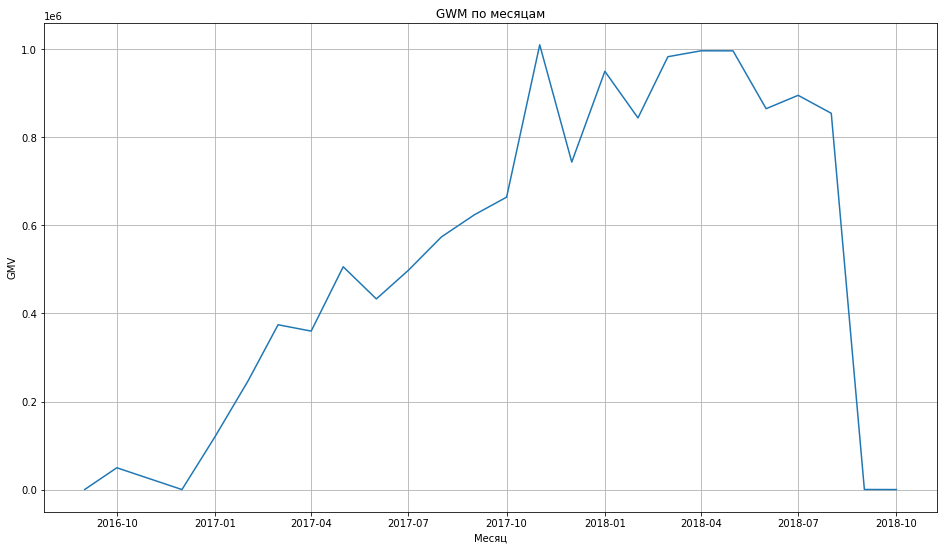

In [32]:
plt.figure(figsize=(16,9))

sns.lineplot(data=gmv_month, x='purchase_month', y='order_total')

plt.title('GWM по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV')

plt.grid(True)
plt.show()

### 2) Метрика, показывающая объем аудитории, которой продукт доставляет ценность: MAU (Monthly Active Users)

In [33]:
# посчитаем количество пользователей в месяц
mau = data_merged.groupby('purchase_month')['customer_unique_id'].nunique().reset_index()

mau['purchase_month'] = mau['purchase_month'].dt.to_timestamp()

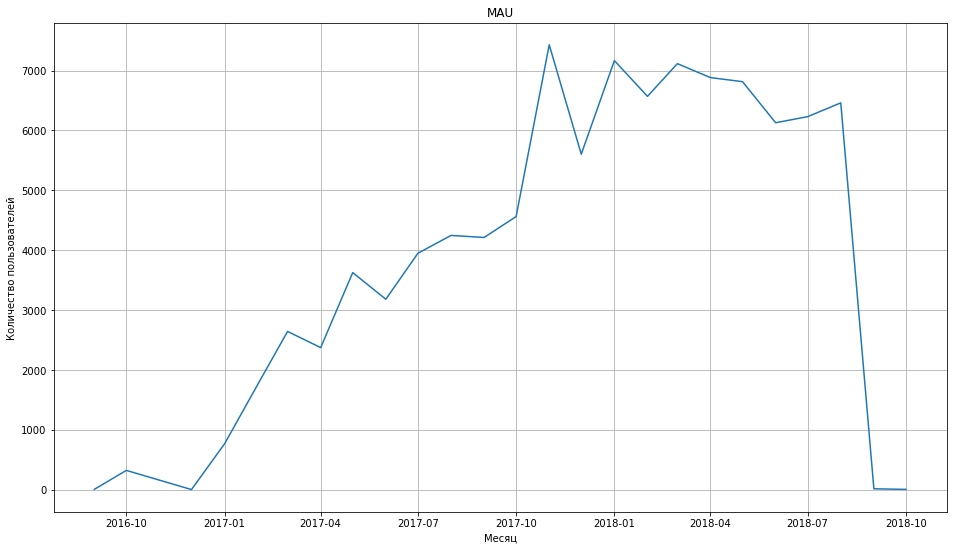

In [34]:
plt.figure(figsize=(16,9))

sns.lineplot(data=mau, x='purchase_month', y='customer_unique_id')

plt.title('MAU')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')

plt.grid(True)
plt.show()

### 3) Метрика, отражающая заинтересованность новых клиентов в покупке: Конверсия в покупку

Конверсия в покупку отражает, сколько новых пользователей совершили хотя бы одну покупку, то есть на сколько новый пользователь не только заинтересовался товаром, но и купил его. Однако у нас нет данных об общем количестве пользователей маркетплейса (данные представлены только по пользователям, которые сделали хотя бы один заказ), в связи с этим конверсию в покупку мы не можем посчитать.

### 4) Метрика, отражающая вовлеченность клиента в продолжение использования продукта: Retention
Другими словами, сколько пользователей возвращаются, чтобы совершить повторную покупку. График медианного retention был построен в задаче 2. Продублируем его ниже, чтобы для наглядности все было в одном месте.

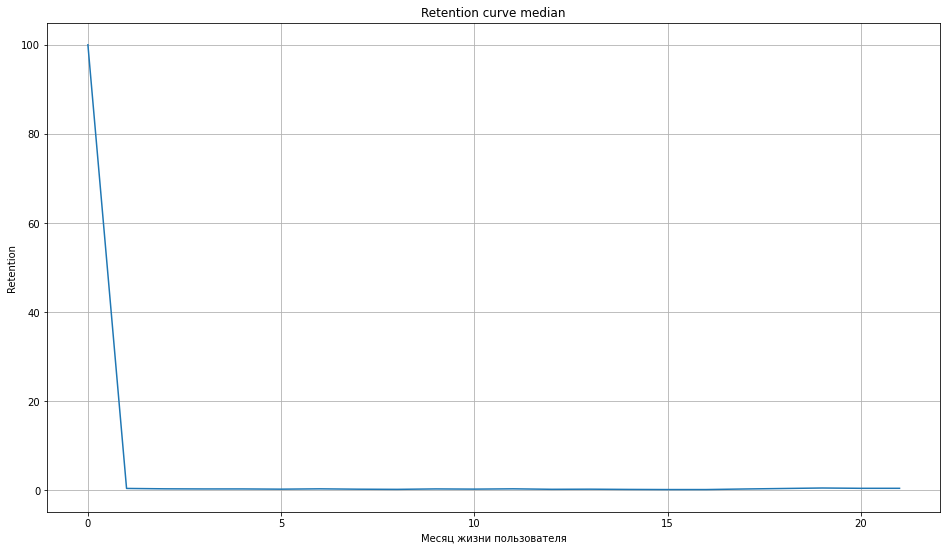

In [35]:
retention_curve = retention_matrix.median() * 100
retention_curve = retention_curve.rename('retention').reset_index().rename(columns={'period_number_month' : 'period'})

plt.figure(figsize=(16, 9))

sns.lineplot(data=retention_curve, x='period', y='retention')

plt.title("Retention curve median")
plt.xlabel('Месяц жизни пользователя')
plt.ylabel('Retention')

plt.grid(True)
plt.show()

### 5) Метрика, отражающая денежное выражение вовлеченности клиента: ARPU (Average Revenue Per User)

Правильнее в данном случае выбрать **LTV** (Lifetime Value), но корректный расчет LTV в нашем случае затруднителен по причине того, что большинство пользователей совершили одну покупку (Число уникальных пользователей (customer_unique_id) составляет 96096, а число заказов (order_id) составляет 99441 (дельта 3345)), время жизни клиента в большинстве ограничено одним периодом, медианный retention меньше 0,5%, а средний чек в основном равен сумме одной покупки. В связи с этим, LTV практически приближается к значению средней выручки на пользователя (ARPU). Поэтому в качестве метрики, отражающей денежное выражение вовлеченности клиента, будем считать **APRU**. 

Нужно понимать, что чистую выручку компании мы не можем посчитать, так как маркетплейс может получать доход с комиссии, рекламы. В нашем случае под выручкой понимается сколько денег пользователь потратит в нашем маркетплейсе (сумма всех его покупок).

In [36]:
# посчитаем среднюю выручку (сумму всех заказов) на пользователя
arpu = (data_merged
        .groupby('purchase_month')
        .agg(revenue=('order_total', 'sum'), 
             users=('customer_unique_id', 'nunique'))
       ).reset_index()

arpu['arpu'] = arpu['revenue'] / arpu['users']

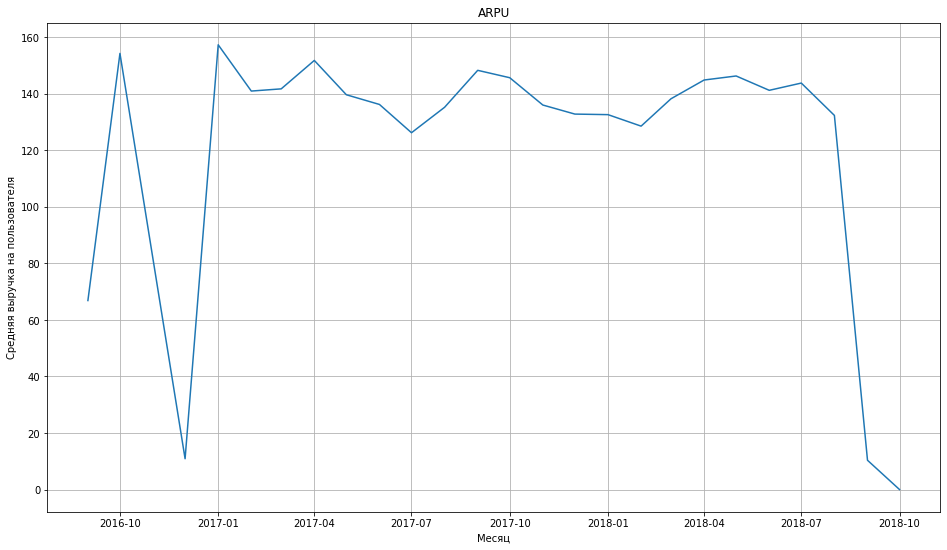

In [37]:
arpu['purchase_month'] = arpu['purchase_month'].dt.to_timestamp()

plt.figure(figsize=(16,9))

sns.lineplot(data=arpu, x='purchase_month', y='arpu')

plt.title('ARPU')
plt.xlabel('Месяц')
plt.ylabel('Средняя выручка на пользователя')

plt.grid(True)
plt.show()

## Выводы по задаче 3:

В качестве метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании были выбраны:

- GMV (Gross Merchendise Value);
- MAU (Monthly Active Users);
- Конверсия в покупку;
- Retention;
- ARPU (Average Revenue Per User).

Помимо упомянутой в задаче 2 проблемы с retention, по графикам видно:
1. GMV: наблюдается рост до ноября 2017, после чего идет постепенный спад, а после августа 2018 GMV резко падает. То есть в нашем случае это значит, что общая сумма заказов стала снижаться. Возможные причины: снижение количество пользователей в месяц, снижение среднего чека, низкий retention.
2. MAU: аналогичная ситуация, что и с GMV, что подтверждает мысль о том, что падение GMV связано со снижением количества пользователей в месяц.
3. ARPU: наблюдается два сильных снижения средней выручки с пользователя: в ноябре-декабре 2016 и в августе 2018. В остальные периоды были небольшие увеличения и снижения средней выручки с пользователя, но не такие значительные как в случае с GMV и MAU, то есть каждый период (кроме ноября-декабря 2016 и августа 2018) маркетплейс получал с пользователя примерно одинаковую сумму денег.
4. Стоит учитывать, что данных недостаточно для корректного и однозначного вывода по метрикам, однако, выбранные метрики стоит отслеживать, чтобы не допустить еще более сильного их снижения.

# Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, мы решили, что нужно изменить продукт. Метрики необходимо повышать. Вместе с командой вы сформулировали 3 гипотезы. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Нужно заполнить самый важный показатель — Impact. 

**Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.**

Для расчёта Impact возьмем данные с **июня 2017 года**. Считаем, что **конверсия в повторный заказ равна величине медианного retention 1-го месяца** (*retention_1_median*).

Гипотезы: 
1. Если **исправим баг в системе процессинга заказов**, то клиентам не придётся сталкиваться с проблемой **отмены заказа**, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

2. Если **сократим время до отгрузки заказа**, то клиенты перестанут получать свой **заказ с запаздыванием**, вследствие чего количество заказов увеличится за счёт повторных заказов.

3. Если создадим **новый способ оплаты**, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

### 1 гипотеза:

*Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.*

В данном случае под багом в системе мы будем понимать случаи, когда заказ **был оплачен пользователем, но был отменен**, а также заказы, которые **были отменены по причине недоступности товара**. 

Мы не берем в расчет заказы, которые были отменены и не были оплачены (данные по order_approved_at отсутствуют), так как это может говорить о том, что пользователь сам отменил заказ и не оплатил его, потому что, например, передумал. 

В то же время, отмененный заказ и отсутствие подтвержденной оплаты может указывать на баг в системе, например, не прошла транзакция, не открылось окно введния данных для оплаты и тд. Однако наши данные не позволяют нам точно установить причину отсутствия подтверждения оплаты в отмененных заказах, поэтому, чтобы не завышать Impact, мы будем считать, что отмененные заказы, у которых нет подтверждения оплаты, были отменены пользователями по их желанию и не будем их учитывать при анализе.

In [38]:
# отберем заказы с июня 2017 года
users_from_june = data_merged[data_merged['purchase_month'] >= '2017-06'].copy()

# отберем заказы, по которым отсутствует информация по сумме заказа и товарных позициях в нем
df_impact_1 = users_from_june.loc[users_from_june.order_total.isnull()]

# отберем заказы со статусом 'canceled', по которым есть оплаты, и все заказы со статусом 'unavailable'
df_impact_1 = pd.concat([
    df_impact_1.loc[df_impact_1['order_status'] == 'unavailable'],
    df_impact_1.loc[(df_impact_1['order_status'] == 'canceled') & (df_impact_1['order_approved_at'].notnull())]
])

# посчитаем количество заказов, которые мы могли бы сохранить
orders_to_save_1 = df_impact_1.order_id.unique()

impact_1 = len(orders_to_save_1)

print(f'Impact гипотезы 1: можно сохранить {int(impact_1)} заказов')

Impact гипотезы 1: можно сохранить 484 заказов


In [39]:
# посмотрим, сколько всего заказов было отменено
canceled_orders = data_merged.query("order_status == 'canceled' or order_status == 'unavailable'")

share_canceled = round(canceled_orders.shape[0] / orders.shape[0] * 100, 2)

print(f'Доля отмененныз заказов: {share_canceled}%')

Доля отмененныз заказов: 1.24%


### 2 гипотеза:

*Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.*

Для оценки Impact выделены пользователи, которые не делали повторный заказ и заказы которых были доставлены позже обещанного срока. Считаем, что для таких пользователей именно факт задержки заказа стал причиной, по которой они не сделали повторный заказ. Предполагается, что устранение задержки доставки позволит вернуть часть этих пользователей и увеличить количество повторных заказов.

In [40]:
# приведем даты к datetime
users_from_june['order_delivered_customer_date'] = pd.to_datetime(users_from_june['order_delivered_customer_date'])
users_from_june['order_estimated_delivery_date'] = pd.to_datetime(users_from_june['order_estimated_delivery_date'])

# найдем заказы, у которых была задержана доставка
delayed_orders = users_from_june[users_from_june['order_delivered_customer_date'] > users_from_june['order_estimated_delivery_date']]

# выделим пользователей, у которых заказ пришел с задержкой
delayed_users = delayed_orders['customer_unique_id'].unique()

In [41]:
# посчитаем количество заказов на пользователя
user_orders = (data_merged
               .groupby('customer_unique_id', as_index=False)
               .agg(order_count=('order_id', 'nunique'))
              )

In [42]:
# выделим пользователей, которые не делали повторный заказ
one_time_users = user_orders[user_orders['order_count'] == 1]['customer_unique_id'].unique()

In [43]:
# преобразуем массивы в датафреймы для удобства
delayed_users_df = pd.DataFrame(delayed_users, columns=['customer_unique_id'])
one_time_users_df = pd.DataFrame(one_time_users, columns=['customer_unique_id'])

# объединим датафремы по customer_unique_id
target_users_df = delayed_users_df.merge(one_time_users_df, on='customer_unique_id')

# посчитаем пользователей, у которых заказ пришел с задержкой и у которых нет повторных заказов
target_users = target_users_df['customer_unique_id'].unique()

In [44]:
# посчитаем impact в пользователях
impact_2_users = len(delayed_users_df)

print(f'Пользователей, ушедших из-за задержки: {impact_2_users}')

# посчитаем количество дополнительных повторных заказов
impact_2 = impact_2_users * retention_1_median

print(f'Impact гипотезы 2: {int(impact_2)} дополнительных заказов')

Пользователей, ушедших из-за задержки: 7246
Impact гипотезы 2: 2569 дополнительных заказов


### 3 гипотеза:
*Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.*

Предполагается, что клиенты испытывают трудности при оформлении заказа, и трудность связана со способом оплаты (так как предлагается создать новый способ оплаты). Если мы это исправим, то увеличится конверся в повторный заказ среди тех, кто ранее не делал повторный заказ.

Для расчета Impact этой гипотезы нам необходимо рассчитать количество пользователей, которые не делали повторный заказ (сделали только один заказ), а также проанализировать, у скольких из этих пользователей были проблемы с оплатой (в нашем случае под проблемой с оплатой понимаем отсутствие подтвержденной оплаты (order_approved_at is null)). 

Если мы возьмем всех пользователей, кто не делал повторный заказ, то мы рискуем завысить Impact, так как не будем брать во внимание трудности при оформлении заказа. Пользователи могли не делать повторный заказ по разным причинам, таким как долгая доставка, маленький ассортимент, высокие цены и прочее.

In [45]:
# находим пользователей с неоплаченными заказами
not_paid = users_from_june[
    users_from_june['order_approved_at'].isnull()
]

not_paid_users = set(not_paid['customer_unique_id'])

# считаем количество заказов каждого пользователя за все время (чтобы не упустить тех, кто когда-либо делал повторный заказ)
user_orders = (
    data_merged
    .groupby('customer_unique_id')
    .agg(order_count=('order_id', 'nunique'))
)

# оставляем только тех, кто не делал повторный заказ (за все время)
one_time_users = set(user_orders[user_orders['order_count'] == 1].index)

# объединяем пользователей с неоплаченными заказами с пользователями, которые не делали повторный заказ
target_users = not_paid_users & one_time_users

In [46]:
# считаем impact в пользователях
impact_3_users = len(target_users)

print(f'Потенциально вернём {impact_3_users} пользователей')

# считаем итоговый impact
impact_3 = impact_3_users * retention_1_median

print(f'Impact гипотезы 3: {int(impact_3)} дополнительных заказов')

Потенциально вернём 64 пользователей
Impact гипотезы 3: 22 дополнительных заказов


In [47]:
# функция для перевода Impact по заданной шкале

def impact_score(metric):
    if metric <= 50:
        return 1
    elif metric <= 150:
        return 2
    elif metric <= 350:
        return 3
    elif metric <= 750:
        return 4
    elif metric <= 1550:
        return 5
    elif metric <= 3150:
        return 6
    elif metric <= 6350:
        return 7
    elif metric <= 12750:
        return 8
    elif metric <= 25550:
        return 9
    elif metric <= 51150:
        return 10

In [48]:
# функция для расчета ICE

def ice(impact, confidence, ease):
    return impact * confidence * ease

In [49]:
# переводим Impact в шкалу
impact_1_score = impact_score(impact_1)
impact_2_score = impact_score(impact_2)
impact_3_score = impact_score(impact_3)

In [50]:
# считаем ICE

ice_1 = ice(impact_1_score, confidence=8, ease=6)
ice_2 = ice(impact_2_score, confidence=10, ease=4)
ice_3 = ice(impact_3_score, confidence=5, ease=9)

print(f"""ICE 1 гипотезы: {ice_1}
ICE 2 гипотезы: {ice_2}
ICE 3 гипотезы: {ice_3}""")

ICE 1 гипотезы: 192
ICE 2 гипотезы: 240
ICE 3 гипотезы: 45


## Вывод по задаче 4:

По итогам ICE приоритетной считается **гипотеза 2**: Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.

Эффект гипотезы 2 по количеству потенциальных повторных заказов, составляет 2569, общий скор по ICE = 240.

К тому же, гипотезы 1 и 3 направлены на избавление от отмен, которых в нашем случае не так много (доля всех отмененных заказов 1.24%), в то время как доля заказов, доставленных с задержкой составляет 7.87%.

# Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

Продакт просит:

- Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
- Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

### Метрики, на которые должна повлиять гипотеза 2:

- Доля повторных заказов (целевая метрика)
    - метрика напрямую отражает пользовательский опыт
    - чувствительная (нужно, чтобы пользователь сделал хотя бы 2 заказа), достоверная (видно, сделал пользователь повторный заказ или нет), интерпретируемая (легко увидеть стали ли пользователи покупать повторно)
- Retention (Целевая метрика)
    - увеличение retention напрямую связано с количеством повторных заказов
    - не очень чувствительна, так как считается через время, не сразу, достоверная (четко показывает, вернулся пользователь или нет), интерпретируемая
- Доля заказов, доставленных в срок (proxy метрика)
    - не влияет напрямую на повторные покупки, но показывает, насколько успешно мы справляемся с сокращением времени доставки 
- Время до передачи заказа в доставку (время сборки заказа) (proxy метрика)
    - не влияет напрямую на повторные покупки, но позволяет увидеть, сколько заказов было собрано вовремя, что связано с итоговым временем доставки клиенту
- Доля отмененных заказов (guardrail метрика)
    - сигнализирует о появлении проблем из-за сокращения времени на сборку заказа и его доставку, из-за которых клиент может отменить доставку (например, статус заказа не успевает корректно синхронизироваться и отображаться у клиента, из-за чего он начинает переживать и отменяет заказ)

# Выводы:

### 1. Среди пользователей маркетплейса мало тех, кто остается после первой покупки (низкий retention)

Это является основной проблемой продукта.

Был проведен когортный анализ, в ходе которого было выявлено, что медианный коэффициент 1-го месяца составляет 0.3546%, а максимальный retention на 3 месяц зафиксирован в январской когорте 2017 года и составил 0.5579%. Медианный коэффициент удержания держится на уровне ниже 0.5%, что говорит о крайне высоком оттоке пользователей после первого заказа. Помимо этого, можно увидеть, что общее количество заказов равняется 99441, а число уникальных пользователей составляет 96096, то есть повторых заказов всего 3345.

### 2. У маркетплейса отсутствует PMF (product/market fit), то есть пользователи не видят ценности в маркетплейсе

Для оценки PMF был проведен когортный анализ, а также построена кривая по медианным retention, отражающая динамику возвращаемости пользователей.

По графику видно, что медианный retention резко снижается после 0-го месяца и стабилизируется на значении меньше 0.5%, что свидетельствует о том, устойчивый спрос у аудитории не обнаружен. 

Было обозначено несколько возможных причин, по которым пользователи не возвращаются к нам:

- Проблемы с логистикой и доставкой. Анализ показал, что 7.87% заказов было доставлено с опозданием, а максимальное время задержки заказа было 205 дней.

- Проблемы с оплатой товаров, например, долгое подтверждение оплаты. В нашем случае среднее время подтверждение оплаты составлят 20 минут (что довольно долго в текущих реалиях) и были случаи, когда подтверждение оплаты превышало несколько дней (17419 клиентов ждали подтверждение оплаты больше 1 дня).

- Отмены заказов, в том числе по причине того, что товара нет в наличии.

- Ассортимент маркетплейса. На маркетплейсе преобладают товары, которые можно купить 1 раз и не возвращаться долгое время. Либо на маркетплейсе в целом довольно скудный ассортимент товаров. В таком случае стоит пересмотреть ассортимент. (Не можем проверить с нашими данными)

- Недостаточная персонализация, непроработанные рекомендации, непроработаны пуш-уведомления, напоминающие пользователям о покупках. (Не можем проверить с нашими данными)

- Отсутствие PCF (product/channel fit). Выбраны неподходящие каналы привлечения аудитории. (Не можем проверить с нашими данными)

### 3. Выбраны метрики, которые позволяет отслеживать состояние продукта и помогут понять, как увеличить прибыль:

- **GMV (Gross Merchendise Value)**
    - отражает рост объема продаж маркетплейса
    - в последние месяцы наблюдается снижение GMV, то есть общая сумма заказов стала снижаться (это может быть связано с высоким оттоком пользователей);
- **MAU (Monthly Active Users)**
    - показывает объем аудитории, которой продукт доставляет ценность
    - аналогично GMV: в последние месяцы наблюдается снижение MAU, что также может быть связано с высоким оттоком пользователей;
- **Конверсия в покупку**
    - отражает заинтересованность новых клиентов в покупке
    - в виду того, что у нас нет данных по общему количеству пользователей маркетплейса (в т.ч. тех, кто не делал заказ), мы не можем оценить эту метрику;
- **Retention**
    - отражает вовлеченность клиента в продолжение использования продукта;
- **ARPU (Average Revenue Per User)**
    - отражает денежное выражение вовлеченности клиента
    - в идеале необходимо отслеживать LTV (lifetime value), однако для подсчета метрики не хватает данных.

### 4. Сформулированы гипотезы, которые помогут улучшить показатели маркетплейса

По результатам когортного анализа и метрик были сформулированы гипотезы:

*1. Если **исправим баг в системе процессинга заказов**, то клиентам не придётся сталкиваться с проблемой **отмены заказа**, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.*
*2. Если **сократим время до отгрузки заказа**, то клиенты перестанут получать свой **заказ с запаздыванием**, вследствие чего количество заказов увеличится за счёт повторных заказов.*
*3. Если создадим **новый способ оплаты**, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.*

Был использован фреймворк ICE, чтобы определить, реализация какой гипотезы приоритетнее. 

По итогам ICE приоритетной считается гипотеза 2. Предполагаемый эффект гипотезы 2: количество повторных заказов увеличится на 2569.

### 5. Гипотеза 2 повлияет на следующие метрики:

- Доля повторных заказов (целевая метрика)
- Retention (Целевая метрика)
- Доля заказов, доставленных в срок (proxy метрика)
- Время до передачи заказа в доставку (время сборки заказа) (proxy метрика)
- Доля отмененных заказов (guardrail метрика)

### Рекомендации:

1. Проанализировать каналы привлечения аудитории и оценить аудиторию, которая приходит на макретплейс (посмотреть есть ли PCF);
2. Собирать данные по выручке и затратам для подсчета LTV, чтобы корректнее подсчитать денежное выражение вовлеченности клиента на всем его жизненном цикле;
3. Сокращать время сборки заказа и время доставки заказа, анализируя приведенные выше метрики для оценки эффекта. Это позволит уменьшить отток пользователей после 1-го заказа;
4. Уделить особое внимание изменению GMV и MAU (будут ли они расти после изменения с временем доставки), так как последние месяцы наблюдается сильное падение по обеим метрикам;
5. Собирать данные по общему количеству пользователям маретплейса, чтобы посчитать конверсию в покупку новых пользователей, это поможет понять, насколько новые пользователи заинтересованы в покупке;
6. Имеются клиенты, у которых время подтверждения оплаты превышает 1 день (17419 клиентов), из-за чего они в том числе могут уходить от нас. Следует собрать данные и проанализировать, с чем связан такой долгий срок подтверждения оплаты.